In [1]:
import numpy as np

In [2]:
import wand
from wand.image import Image
from wand.drawing import Drawing

In [3]:
import math

In [4]:
import matplotlib.pyplot as plt

In [5]:
dt = np.dtype([('frame', np.int32), 
               ('Rd','<i8'),('Rx',np.int16),('Ry',np.int16),
               ('Gd','<i8'),('Gx',np.int16),('Gy',np.int16),
               ('Bd','<i8'),('Bx',np.int16),('By',np.int16),
               ('rd','<i8'),('rx',np.int16),('ry',np.int16),
               ('gd','<i8'),('gx',np.int16),('gy',np.int16),
               ('bd','<i8'),('bx',np.int16),('by',np.int16),
               ('Rn',np.int32),('Gn',np.int32),('Bn',np.int32),
               ('rn',np.int32),('gn',np.int32),('bn',np.int32),
               ('stn',np.int32)]
             )

In [6]:
intdata = np.loadtxt("DroneShort1HalfDecimated.int.1.txt",converters=float,dtype=dt)

IPath="/media/seth/CTAP/bitmaps-jobDS1HalfDecimatedFRAME"

In [7]:
def to6( n ):
    return "{!s:>06}".format(n)
def tothumb(n):
    return IPath+"/thumb"+to6(n)+".bmp"
tothumb(1234)

'/media/seth/CTAP/bitmaps-jobDS1HalfDecimatedFRAME/thumb001234.bmp'

In [8]:
width=0
height=0
def setwh(n):
    img=Image(filename=tothumb(1))
    global width
    width=img.width
    global height
    height=img.height
setwh(1)

Setup for drawing the data line.

In [9]:
llcapx=int(width/20)
llcapy=int(height-width/20)

In [10]:
drdbl=Drawing()
drgbl=drdbl.clone()
drdbl.font_size=30
drdbl.fill_color="WHITE"
drdbl.stroke_color="WHITE"

Setup for drawing markers on Phase1a selected pixels.

In [11]:
def M(TH) :
    return( np.array( [ [math.cos(math.pi*TH/180.), math.sin(math.pi*TH/180.)], [-math.sin(math.pi*TH/180.), math.cos(math.pi*TH/180.)] ] ) )

#Geometry of normalized unit arrows to show RGB changes
TH=30.0                  #angle of arrows away from vertical, and hands away from body
lcircr=0.1               #little circle radius
hslen=0.1                #length of each hand of an
# Unit Vectors
g1=np.array([0.0,1.0])   #unit lower case, down, green

#tiny vectors
tc=lcircr*np.array([0.0,1.0]) #radius (down, y dir of tiny circle, and foot of down unit arrow
def T(s) :
    return (tc + g1*s) #tail on tiny circle, head down by unit * s (scale, 0<=s<=1)

#Arrow body is (tc->T(s)*M..
def arrB(s) :
    return np.array([tc, T(s)])

TL=hslen*g1@M(180.0+TH) #coord of left hand rel to head
TR=hslen*g1@M(180.0-TH) #coord of right hand rel to head

#down dir Left arm LA(s) is (T(s)->TL(s))
def arrL(s) :
    return np.array([T(s), T(s)+TL])


#down dir Right arm LA(s) is (T(s)->TL(s))
def arrR(s) :
    return np.array([T(s), T(s)+TR])

def unit_up_arrow(s) :
    return -np.concat([arrB(s),arrL(s),arrR(s)])


In [12]:
def dispdata(row):
    #print(fn, row['frame'])
    return ( [ row['Rd'],   -30.0, [row['Rx'],row['Ry']], row['Rn' ], "red" ],
             [ row['Gd'],     0.0, [row['Gx'],row['Gy']], row['Gn' ], "green" ],
             [ row['Bd'],    30.0, [row['Bx'],row['By']], row['Bn' ], "blue" ],
             [ -row['rd'], -150.0, [row['rx'],row['ry']], row['rn' ], "red" ],
             [ -row['gd'],  180.0, [row['gx'],row['gy']], row['gn' ], "green" ],
             [ -row['bd'],  150.0, [row['rx'],row['by']], row['bn' ], "blue" ] )             

In [13]:
colvaldiv = float(128)
arrlen = 100

def drdata(dwg, row):
    data = dispdata(row)
    for r in data:
        #print(r)
        #print((r[0]/colvaldiv))
        #print( "arrow", arrlen*unit_up_arrow( (r[0]/colvaldiv)) )
        line = np.round( (arrlen*unit_up_arrow(r[0]/colvaldiv))@M(r[1]) + r[2]).astype(int)
        dwg.stroke_width = 2
        dwg.stroke_color = wand.color.Color( r[4] )
        for i in range(0,3):
            dwg.line(line[2*i],line[2*i+1])

In [14]:
img=0
def vis(fn):
    global img
    img=Image(filename=tothumb(fn))
    row=np.array(intdata[fn-1])
    t=intdata[fn-1].item(0)
    intdatarowstr = str(t[0])
    for z in range(1,24,3):
        intdatarowstr+=" "+str(t[z:z+3])
    intdatarowstr+="  "+str(t[24])
    global drdbl
    draw=drdbl.clone()
    draw.text(llcapx,llcapy,intdatarowstr)
    drdata(draw, row )
    draw(img)
    #draw
    #draw(img)
    return img #so jupyter tries to print the result which makes the picture appear!      

In [15]:
#vis(319)

In [16]:
row=intdata[0]
row

np.void((1, 12, 19, 489, 12, 19, 489, 12, 19, 489, -11, 16, 499, -11, 16, 499, -11, 16, 499, 0, 0, 0, 0, 0, 0, 0), dtype=[('frame', '<i4'), ('Rd', '<i8'), ('Rx', '<i2'), ('Ry', '<i2'), ('Gd', '<i8'), ('Gx', '<i2'), ('Gy', '<i2'), ('Bd', '<i8'), ('Bx', '<i2'), ('By', '<i2'), ('rd', '<i8'), ('rx', '<i2'), ('ry', '<i2'), ('gd', '<i8'), ('gx', '<i2'), ('gy', '<i2'), ('bd', '<i8'), ('bx', '<i2'), ('by', '<i2'), ('Rn', '<i4'), ('Gn', '<i4'), ('Bn', '<i4'), ('rn', '<i4'), ('gn', '<i4'), ('bn', '<i4'), ('stn', '<i4')])

In [17]:
row['frame']

np.int32(1)

In [18]:
l2=(row['Rd'],[row['Rx'],row['Ry']])[1]

In [19]:
type(l2@np.array([[1,0],[0,1]]))

numpy.ndarray

In [20]:
print(tc)
print(T(0.7))
print(arrB(0.7))
print(T(0.7))
print(arrB(0.7))
print(TL)
print(arrL(0.7))
print(unit_up_arrow(0.7))
print()
print(unit_up_arrow(1.0))

[0.  0.1]
[0.  0.8]
[[0.  0.1]
 [0.  0.8]]
[0.  0.8]
[[0.  0.1]
 [0.  0.8]]
[ 0.05       -0.08660254]
[[0.         0.8       ]
 [0.05       0.71339746]]
[[-0.         -0.1       ]
 [-0.         -0.8       ]
 [-0.         -0.8       ]
 [-0.05       -0.71339746]
 [-0.         -0.8       ]
 [ 0.05       -0.71339746]]

[[-0.         -0.1       ]
 [-0.         -1.1       ]
 [-0.         -1.1       ]
 [-0.05       -1.01339746]
 [-0.         -1.1       ]
 [ 0.05       -1.01339746]]


In [21]:
mar=unit_up_arrow(0.5)
print( mar )
print( mar[:,0] )
print( mar[:,1] )

[[-0.         -0.1       ]
 [-0.         -0.6       ]
 [-0.         -0.6       ]
 [-0.05       -0.51339746]
 [-0.         -0.6       ]
 [ 0.05       -0.51339746]]
[-0.   -0.   -0.   -0.05 -0.    0.05]
[-0.1        -0.6        -0.6        -0.51339746 -0.6        -0.51339746]


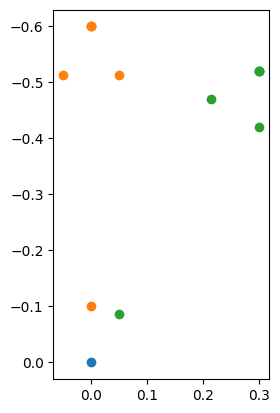

In [22]:
fig, ax = plt.subplots()# Create a figure containing a single Axes.
ax.set_aspect('equal')
ax.yaxis.set_inverted('true')
ax.scatter( [0], [0] )
ax.scatter(mar[:,0], mar[:,1]) # Plot some data on the Axes.
mar=mar@M(30)
ax.scatter(mar[:,0], mar[:,1]) # Plot some data on the Axes.
plt.show()                           # Show the figure.

In [23]:
def dispdata(alld, fn):
    row = alld[fn-1];
    #print(fn, row['frame'])
    return ( [ row['Rd'],   -30.0, [row['Rx'],row['Ry']], row['Rn' ], "red" ],
             [ row['Gd'],     0.0, [row['Gx'],row['Gy']], row['Gn' ], "green" ],
             [ row['Bd'],    30.0, [row['Bx'],row['By']], row['Bn' ], "blue" ],
             [ -row['rd'], -150.0, [row['rx'],row['ry']], row['rn' ], "red" ],
             [ -row['gd'],  180.0, [row['gx'],row['gy']], row['gn' ], "green" ],
             [ -row['bd'],  150.0, [row['rx'],row['by']], row['bn' ], "blue" ] )             

In [24]:
dwg=Drawing()

In [25]:
drdata(dwg, intdata, 3)

TypeError: drdata() takes 2 positional arguments but 3 were given

In [ ]:
print(lastline)
fig, ax = plt.subplots()# Create a figure containing a single Axes.
ax.set_aspect('equal')
ax.yaxis.set_inverted('true')
ax.scatter(lastline[:,0],lastline[:,1])
plt.show()                           # Show the figure.

In [ ]:
ax.scatter(lastline[:,0],lastline[:,1])
plt.show()

In [ ]:
dr2=Drawing()

In [ ]:
spot=np.array([557,200])
arrmult=30

In [ ]:
arr=(arrmult*arrB(0.5)+spot,arrmult*arrL(0.5)+spot,arrmult*arrR(0.5)+spot)

In [ ]:
a=arr[0]


In [ ]:
dr2.line(a[0],a[1])

In [ ]:
dr2.line(arr[1][0],arr[1][1])

In [ ]:
dr2.line(arr[2][0],arr[2][1])


In [ ]:
dr2(img)

In [ ]:
dr2=Drawing()

In [ ]:
dr2.fill_opacity = 0

In [ ]:
dr2.stroke_width = 2

In [ ]:
dr2.stroke_color = wand.color.Color('black')

In [ ]:
dr2.circle((500,500),(500-10,500-10))

In [ ]:
dr2.line((500,500+10),(500,500+30))

In [ ]:
dr2(img)

In [ ]:
input[['frame','stn']][0][['frame','stn']]

In [ ]:
type(input[0])

In [ ]:
len(input)

In [ ]:
ary=np.array(input)

In [ ]:
type(ary)

In [ ]:
row=np.array(ary[0])

In [ ]:
row

In [ ]:
type(row)

In [ ]:
type(ary[0])

In [ ]:
type(row)

In [ ]:
row.item(0)[0]

In [ ]:
 type(row.base)

In [26]:
Drawing.circle??

Signature: Drawing.circle(self, origin, perimeter)
Source:   
    def circle(self, origin, perimeter):
        """Draws a circle from ``origin`` to ``perimeter``

        :param origin: (:class:`~numbers.Real`, :class:`numbers.Real`)
                       pair which represents origin x and y of circle
        :type origin: :class:`collections.abc.Sequence`
        :param perimeter: (:class:`~numbers.Real`, :class:`numbers.Real`)
                       pair which represents perimeter x and y of circle
        :type perimeter: :class:`collections.abc.Sequence`

        .. versionadded:: 0.4.0

        """
        assertions.assert_coordinate(origin=origin, perimeter=perimeter)
        origin_x, origin_y = origin
        perimeter_x, perimeter_y = perimeter
        library.DrawCircle(self.resource, origin_x, origin_y,
                           perimeter_x, perimeter_y)
File:      /data/Software/sklearn-venv/lib/python3.10/site-packages/wand/drawing.py
Type:      function